# Variability across contacts in the SC state

# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

# Panel - 3 contacts nD map

/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


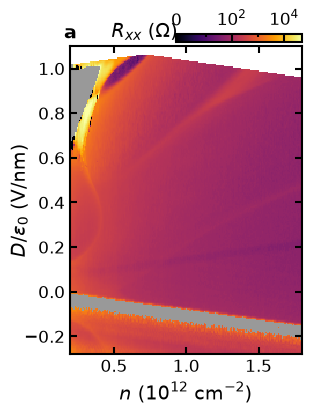

In [4]:
def plot_gatemap(ax, norm, cmap="viridis", contact_ind=1):
    
    files= [1948] 
    ns = np.array([0.2, 0.72, 1.8, 1.8, 0.2])
    Ds = np.array([1.018, 1.065, 0.96, -0.4, -0.4])
    
    nx, ny = 201, 251
    
    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long bot': {'indices': [contact_ind], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                z_arr.append(zs)
                
                finite = np.isfinite(I)
                mask = np.abs(I) < 0.5 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)
        
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)', labelpad=-4)
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(-0.28, 1.1)
        return plot


fig = plt.figure(figsize=(3,4))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=5E4)
plot = plot_gatemap(ax, norm, "inferno", 3)

fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')
cb_width = 0.42
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

# Full figure

/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


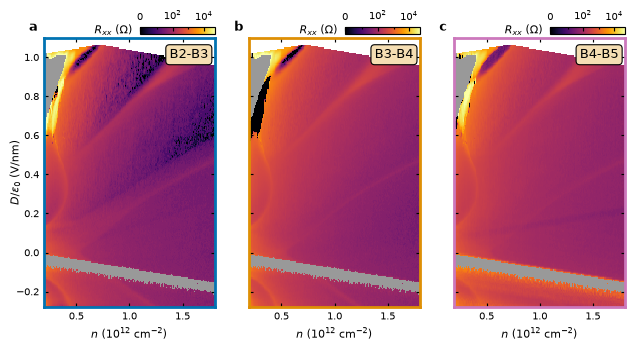

In [5]:
update_rc_params('paper')  # paper style for this final figure

fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(1, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1],
                       hspace=0.2, wspace=0.2)

################ Panel a,b,c ##################
labels = ["a", "b", "c"]
contact_labels = ["B2-B3", "B3-B4", "B4-B5"]
contact_colors = ["#0173B2", "#DE8F05", "#CC78BC"]
for subfig_ind, contact_ind in enumerate([1,2,3]):
    ax = fig.add_subplot(gs[0, subfig_ind])
    norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=5E4)
    plot = plot_gatemap(ax, norm, "inferno", contact_ind)

    if subfig_ind in [1,2]:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    fig.canvas.draw()  
    pos = ax.get_position()
    label_spacer = 0.02
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, labels[subfig_ind], fontweight='bold')
    cb_width = 0.10
    cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    
    cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                      orientation='horizontal')
    cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
    cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
    cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
    cb.ax.xaxis.set_label_position('top')

    for spine in ax.spines.values():
        spine.set_visible(True)      # or False to hide
        spine.set_linewidth(2)        # thickness
        spine.set_edgecolor(contact_colors[subfig_ind])
    ax.text(0.96, 0.96, contact_labels[subfig_ind], transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
fig.savefig("ed-fig-contact-var.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default


/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/tmp/ipykernel_760899/2783869122.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


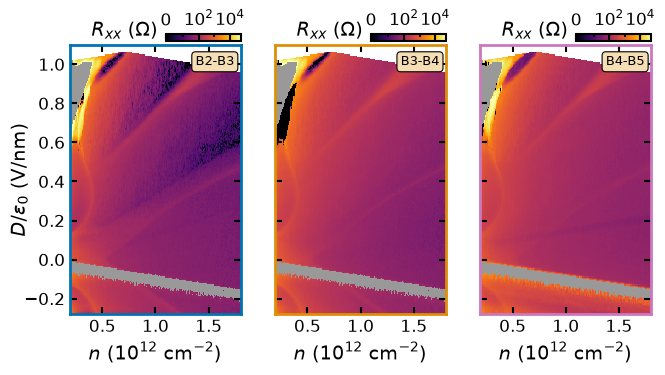

['/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-contact-var.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-contact-var.png']

In [6]:
update_rc_params('talk')  # paper style for this final figure

fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(1, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1],
                       hspace=0.2, wspace=0.2)

################ Panel a,b,c ##################
labels = ["a", "b", "c"]
contact_labels = ["B2-B3", "B3-B4", "B4-B5"]
contact_colors = ["#0173B2", "#DE8F05", "#CC78BC"]
for subfig_ind, contact_ind in enumerate([1,2,3]):
    ax = fig.add_subplot(gs[0, subfig_ind])
    norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=5E4)
    plot = plot_gatemap(ax, norm, "inferno", contact_ind)

    if subfig_ind in [1,2]:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    fig.canvas.draw()  
    pos = ax.get_position()
    label_spacer = 0.02
    # fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, labels[subfig_ind], fontweight='bold')
    cb_width = 0.10
    cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    
    cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                      orientation='horizontal')
    cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
    cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 1.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
    cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
    cb.ax.xaxis.set_label_position('top')

    for spine in ax.spines.values():
        spine.set_visible(True)      # or False to hide
        spine.set_linewidth(2)        # thickness
        spine.set_edgecolor(contact_colors[subfig_ind])
    ax.text(0.96, 0.96, contact_labels[subfig_ind], transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
fig.savefig("ed-fig-contact-var.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)


save_fig(fig, "ed-fig-contact-var")